In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [2]:
from keras.datasets import mnist

In [20]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [24]:
x_test.shape

(10000, 28, 28)

In [23]:
X_train.shape

(60000, 28, 28)

In [25]:
from sklearn.neighbors import KNeighborsClassifier


In [26]:
knn=KNeighborsClassifier()

In [27]:
knn.fit(X_train.reshape(len(X_train),-1),y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
y_prd=knn.predict(X_test.reshape(len(X_test),-1))

In [47]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_prd)

0.9575

In [30]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()

In [31]:
X_train=scalar.fit_transform(X_train.reshape(len(X_train),-1))
X_test=scalar.transform(X_test.reshape(len(X_test),-1))

In [34]:
from sklearn.decomposition import PCA
pca=PCA(n_components=100)

In [36]:
X_train_trf=pca.fit_transform(X_train)
X_test_trf=pca.transform(X_test)

In [39]:
knn.fit(X_train_trf, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
X_train_trf.shape

(60000, 100)

In [44]:
y_prd=knn.predict(X_test_trf)

In [48]:
accuracy_score(y_test,y_prd)

0.9575

In [50]:
for i in range(1,35):
    pca=PCA(n_components=i)
    X_train_trf=pca.fit_transform(X_train)
    X_test_trf=pca.transform(X_test)
    knn.fit(X_train_trf, y_train)
    y_prd=knn.predict(X_test_trf)
    acc=accuracy_score(y_test,y_prd)
    print(f'Number of components:{i},Accuracy:{acc}')

Number of components:1,Accuracy:0.2563
Number of components:2,Accuracy:0.3197
Number of components:3,Accuracy:0.5194
Number of components:4,Accuracy:0.668
Number of components:5,Accuracy:0.738
Number of components:6,Accuracy:0.8348
Number of components:7,Accuracy:0.8453
Number of components:8,Accuracy:0.876
Number of components:9,Accuracy:0.8893
Number of components:10,Accuracy:0.9075
Number of components:11,Accuracy:0.9146
Number of components:12,Accuracy:0.9202
Number of components:13,Accuracy:0.928
Number of components:14,Accuracy:0.9362
Number of components:15,Accuracy:0.9378
Number of components:16,Accuracy:0.9387
Number of components:17,Accuracy:0.9409
Number of components:18,Accuracy:0.9416
Number of components:19,Accuracy:0.9457
Number of components:20,Accuracy:0.946
Number of components:21,Accuracy:0.9462
Number of components:22,Accuracy:0.9471
Number of components:23,Accuracy:0.9491
Number of components:24,Accuracy:0.949
Number of components:25,Accuracy:0.9493
Number of compo

In [56]:
import plotly.express as px
y_train_trf=y_train.astype(str)
fig=px.scatter_3d(
    x=X_train_trf[:,0],
    y=X_train_trf[:,1],
    z=X_train_trf[:,2],
    color=y_train_trf,
    title='PCA of MNIST dataset'
)
fig.show()  

In [58]:
pca.explained_variance_

array([40.48763511, 29.24169752, 26.81180449, 20.68661822, 18.07665012,
       15.73317787, 13.79060909, 12.51758909, 11.00679527, 10.05049705,
        9.62045779,  8.63097356,  7.99159687,  7.81488215,  7.37553786,
        7.13058751,  6.71398002,  6.60400749,  6.40604846,  6.23737743,
        5.93229172,  5.76059855,  5.48403364,  5.31859721,  5.12873534,
        4.96062446,  4.90533662,  4.70843497,  4.5291976 ,  4.39470849,
        4.27522172,  4.21399693,  4.09838079,  4.03181137])

In [60]:
pca.components_.shape

(34, 100)

In [62]:
np.cumsum(pca.explained_variance_ratio_)

array([0.079988  , 0.13775835, 0.19072817, 0.23159697, 0.26730948,
       0.29839219, 0.32563713, 0.35036708, 0.37211227, 0.39196819,
       0.41097452, 0.428026  , 0.44381432, 0.45925353, 0.47382475,
       0.48791205, 0.50117629, 0.51422327, 0.52687916, 0.53920182,
       0.55092175, 0.56230248, 0.57313682, 0.58364432, 0.59377673,
       0.60357702, 0.61326808, 0.62257013, 0.63151809, 0.64020034,
       0.64864654, 0.65697177, 0.6650686 , 0.67303391])

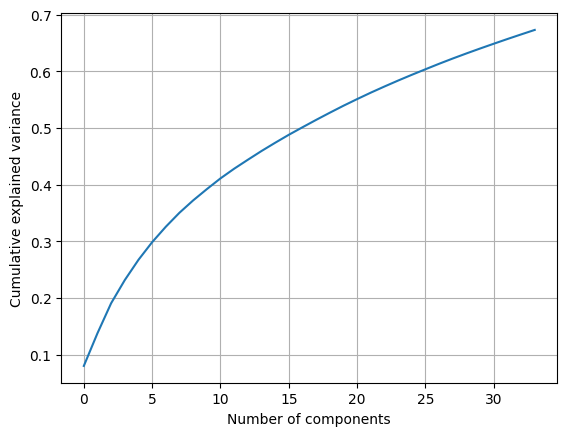

In [63]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.grid()
plt.show()